# Análise de Métricas de Qualidade — Código Java com Contribuição do Claude (IA)

**Instale as dependências antes de rodar:**
```
pip install pandas matplotlib seaborn scipy scikit-learn statsmodels
```

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
ALPHA = 0.05

## 1. Carregamento e pré-processamento

In [2]:
df_raw = pd.read_csv('../data/dataset.csv')
print(f'Shape inicial: {df_raw.shape}')
print(f'Repos ({df_raw["repo"].nunique()}): {list(df_raw["repo"].unique())}')

Shape inicial: (1252, 20)
Repos (10): ['sivaprasadreddy/talk-to-repo', 'adamzwasserman/honest-code-traces', 'Kyu-seok/CodeBite', 'nxmatic/rke2lab', 'cloudempiere/com.cloudempiere.searchindex', 'akrishnanDG/schematizer-skill', 'tim-mila/golf-api', 'JackZho/android-library-system', 'JackZho/MusicPlayer', 'shossain786/utem-core']


In [3]:
# Remove colunas de identificação e colunas constantes (análise estática zerada)
DROP = ['class', 'file', 'WarningMajor', 'Design_Rules', 'Coupling_Metric_Rules',
        'Documentation_Metric_Rules', 'Size_Metric_Rules', 'Number_of_bugs']
df = df_raw.drop(columns=DROP, errors='ignore').dropna().copy()
METRICAS = [c for c in df.columns if c != 'repo']
print(f'Shape final: {df.shape}')
print(f'Métricas ({len(METRICAS)}): {METRICAS}')

Shape final: (1191, 12)
Métricas (11): ['LOC', 'CLOC', 'WMC', 'CBO', 'RFC', 'DIT', 'LCOM5', 'NM', 'NPM', 'McCC_avg', 'McCC_max']


## 2. Estatística descritiva

In [4]:
desc = df[METRICAS].describe(percentiles=[.25,.5,.75,.90,.95]).T
desc['amplitude'] = desc['max'] - desc['min']
desc = desc[['mean','50%','25%','75%','90%','95%','max','amplitude','std']]
desc.columns = ['Média','Mediana','Q1','Q3','P90','P95','Máximo','Amplitude','DP']
desc.round(2)

,Média,Mediana,Q1,Q3,P90,P95,Máximo,Amplitude,DP
LOC,138.44,110.0,32.5,188.50,274.0,406.5,1485.0,1479.0,142.52
CLOC,9.75,2.0,1.0,11.00,28.0,41.0,396.0,396.0,20.89
WMC,7.53,5.0,1.0,10.00,17.0,21.5,115.0,115.0,9.43
CBO,5.05,4.0,2.0,7.00,12.0,14.0,22.0,22.0,4.36
RFC,42.97,18.0,6.0,39.00,110.0,186.0,818.0,817.0,75.15
DIT,0.23,0.0,0.0,0.00,1.0,1.0,1.0,1.0,0.42
LCOM5,0.43,0.5,0.0,0.85,1.0,1.0,1.0,1.0,0.41
NM,5.64,4.0,1.0,8.00,13.0,17.0,84.0,84.0,5.91
NPM,4.44,2.0,1.0,7.00,12.0,15.5,84.0,84.0,5.89
McCC_avg,1.33,1.0,1.0,1.20,2.0,3.0,12.0,11.0,0.89


In [5]:
# Moda por métrica
pd.Series({c: df[c].mode().iloc[0] for c in METRICAS}, name='Moda').to_frame()

,Moda
LOC,6.0
CLOC,2.0
WMC,1.0
CBO,4.0
RFC,1.0
DIT,0.0
LCOM5,0.0
NM,1.0
NPM,1.0
McCC_avg,1.0


## 3. Distribuição e normalidade (Kolmogorov-Smirnov)

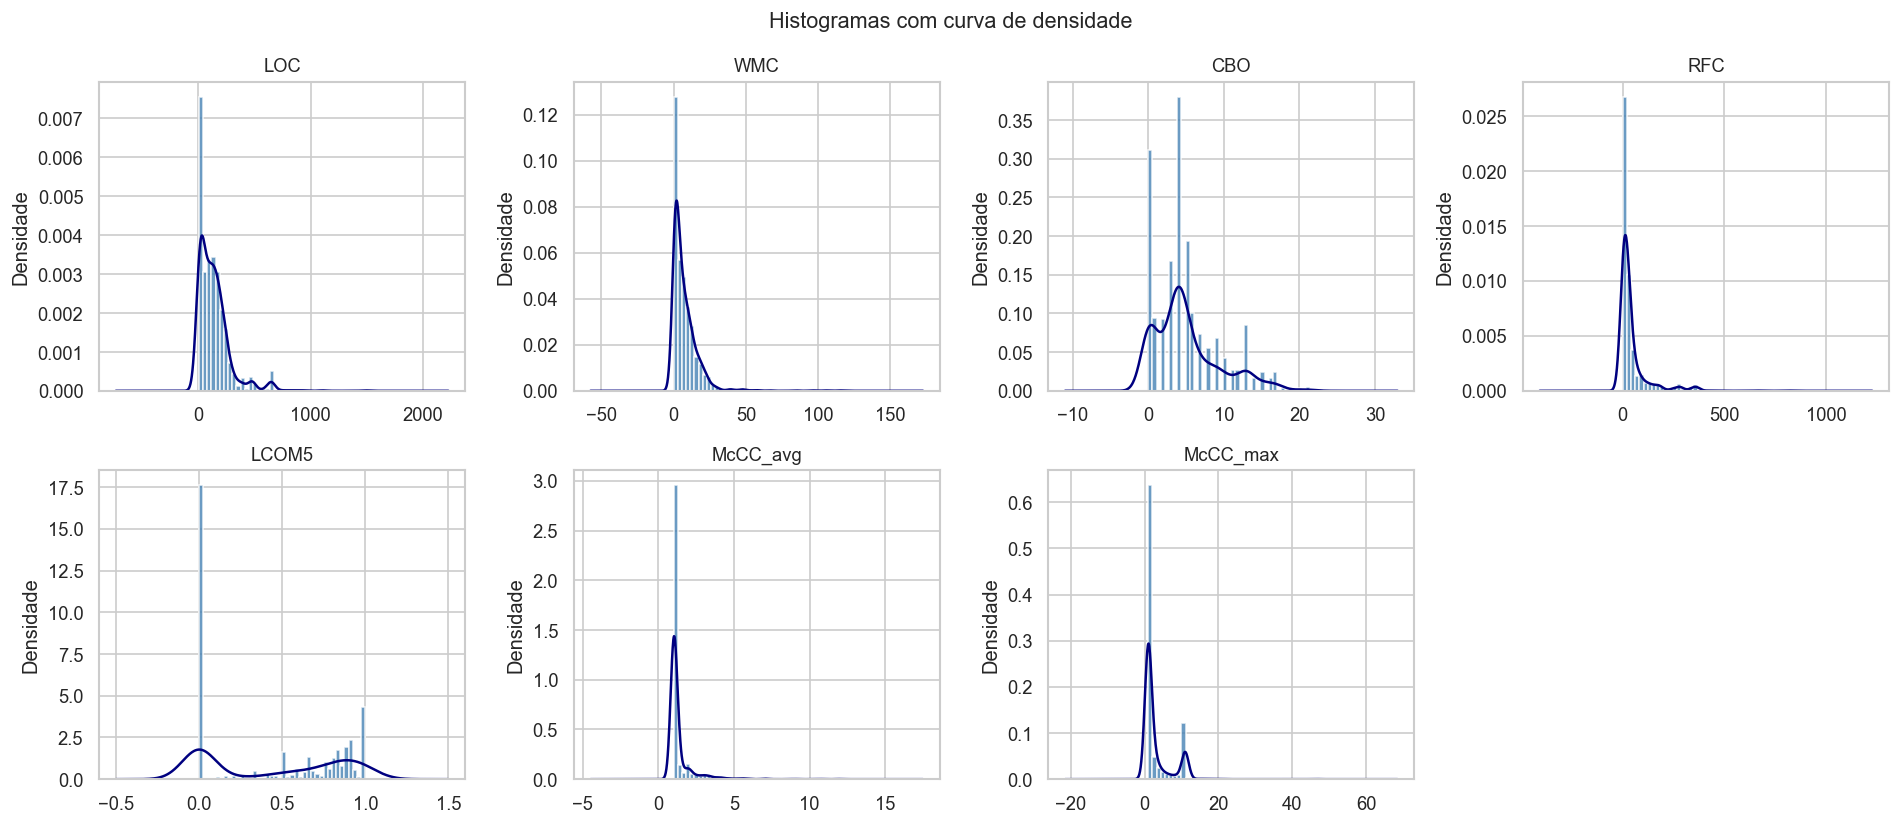

In [6]:
PLOT_COLS = ['LOC','WMC','CBO','RFC','LCOM5','McCC_avg','McCC_max']
PLOT_COLS = [c for c in PLOT_COLS if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(PLOT_COLS):
    axes[i].hist(df[col], bins=40, color='steelblue', alpha=0.8, density=True, edgecolor='white')
    df[col].plot.kde(ax=axes[i], color='navy', lw=1.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Densidade')
for j in range(len(PLOT_COLS), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Histogramas com curva de densidade', fontsize=13)
plt.tight_layout()
plt.savefig('normalidade.png', bbox_inches='tight')
plt.show()

In [7]:
ks = []
for col in METRICAS:
    d = df[col].dropna()
    stat, pval = stats.kstest(d, 'norm', args=(d.mean(), d.std()))
    ks.append({'Variável': col, 'D': round(stat,4), 'p-valor': f'{pval:.2e}',
               'Normal': 'Não' if pval < ALPHA else 'Sim'})
pd.DataFrame(ks).set_index('Variável')

,D,p-valor,Normal
Variável,,,
LOC,0.1764,7.02e-33,Não
CLOC,0.3203,3.57e-109,Não
WMC,0.2425,3.85e-62,Não
CBO,0.1872,5.39e-37,Não
RFC,0.2883,4.11e-88,Não
DIT,0.4760,2.23e-248,Não
LCOM5,0.2916,3.51e-90,Não
NM,0.2146,1.25e-48,Não
NPM,0.2255,1.10e-53,Não


## 4. Outliers (critério IQR)

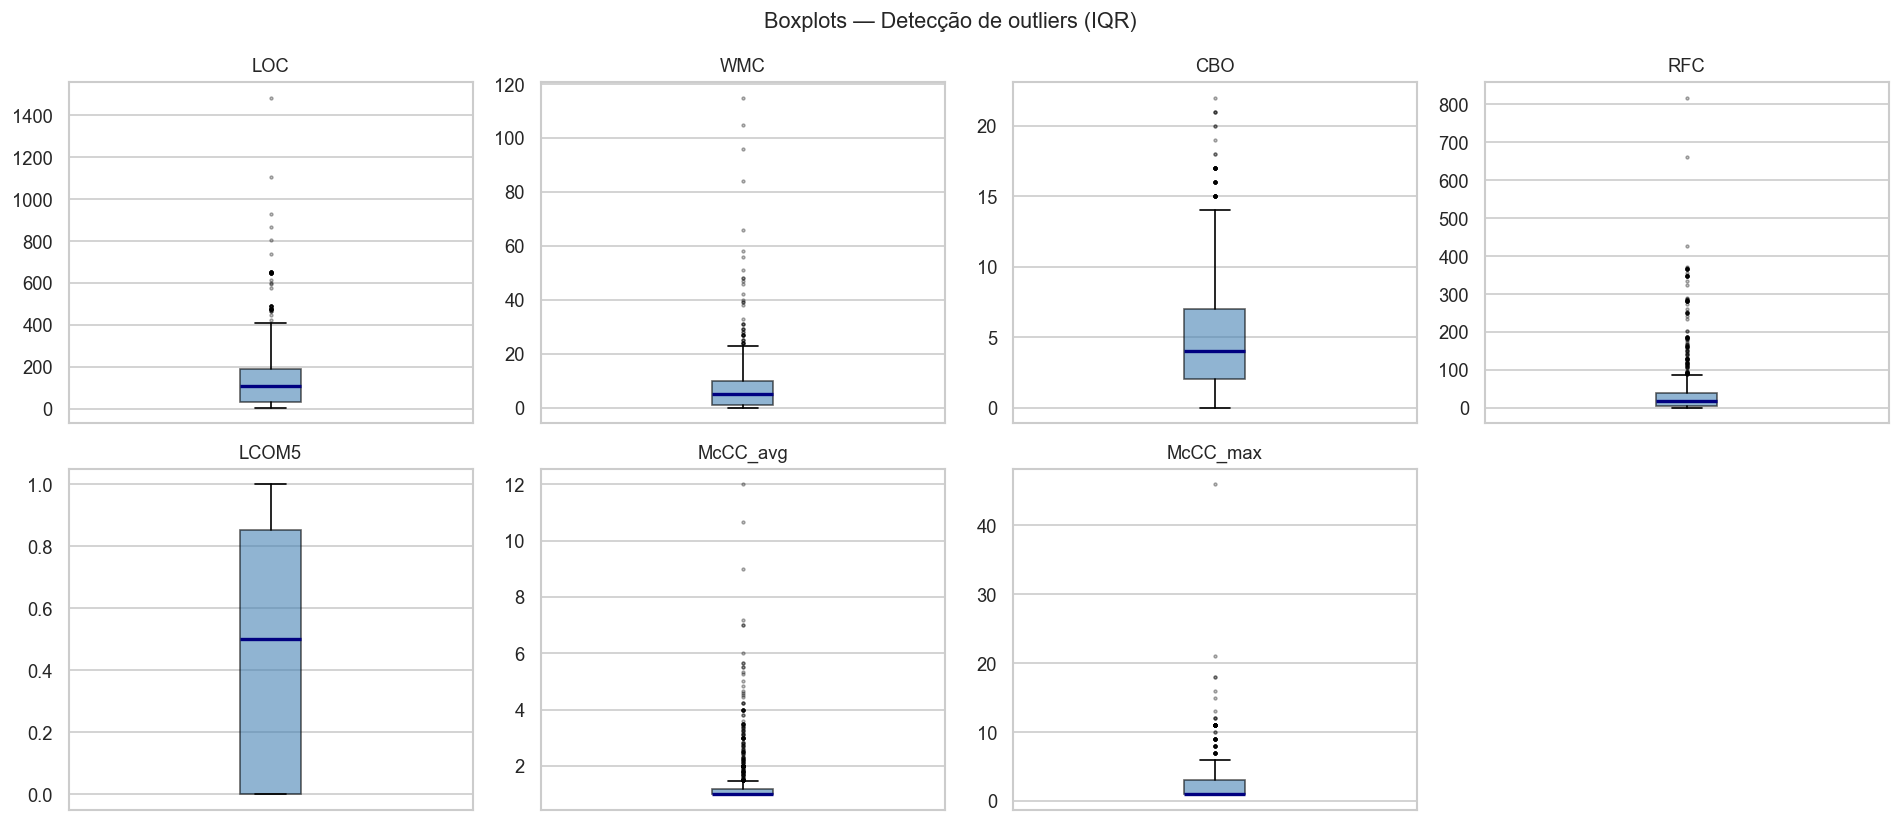

Outliers por variável:
  LOC         :   58 (4.9%)
  CLOC        :  125 (10.5%)
  WMC         :   40 (3.4%)
  CBO         :   52 (4.4%)
  RFC         :  145 (12.2%)
  DIT         :  278 (23.3%)
  LCOM5       :    0 (0.0%)
  NM          :   42 (3.5%)
  NPM         :   51 (4.3%)
  McCC_avg    :  200 (16.8%)
  McCC_max    :  207 (17.4%)


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(PLOT_COLS):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='navy', lw=2),
                    flierprops=dict(marker='.', ms=3, alpha=0.4))
    axes[i].set_title(col, fontsize=11); axes[i].set_xticks([])
for j in range(len(PLOT_COLS), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots — Detecção de outliers (IQR)', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot.png', bbox_inches='tight')
plt.show()

print('Outliers por variável:')
for col in METRICAS:
    q1,q3 = df[col].quantile([.25,.75])
    iqr = q3-q1
    n = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    print(f'  {col:12s}: {n:4d} ({n/len(df)*100:.1f}%)')

## 5. Detecção de code smells por threshold

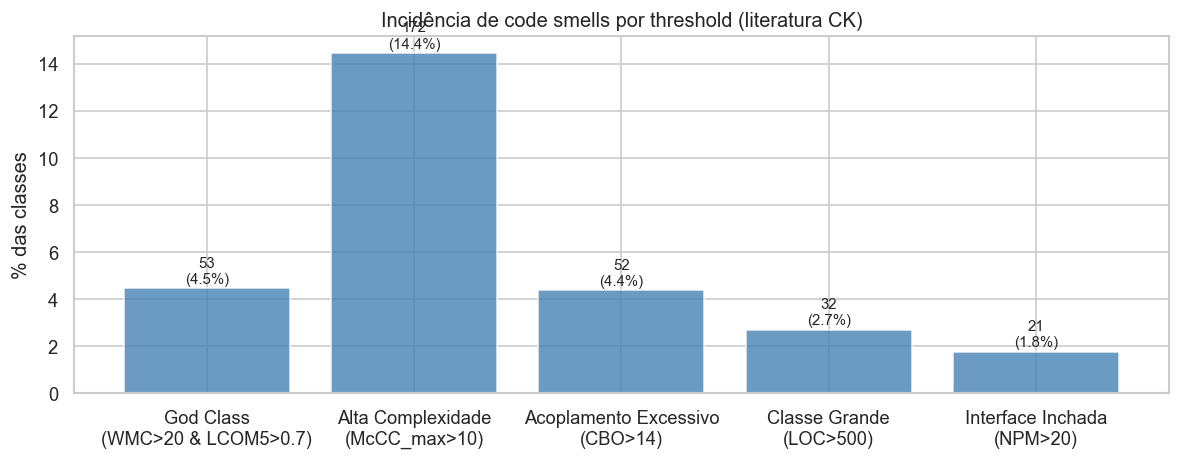

  God Class (WMC>20 & LCOM5>0.7)          :   53 (4.5%)
  Alta Complexidade (McCC_max>10)         :  172 (14.4%)
  Acoplamento Excessivo (CBO>14)          :   52 (4.4%)
  Classe Grande (LOC>500)                 :   32 (2.7%)
  Interface Inchada (NPM>20)              :   21 (1.8%)


In [9]:
smells = {
    'God Class\n(WMC>20 & LCOM5>0.7)':   ((df['WMC'] > 20) & (df['LCOM5'] > 0.7)).sum(),
    'Alta Complexidade\n(McCC_max>10)':    (df['McCC_max'] > 10).sum(),
    'Acoplamento Excessivo\n(CBO>14)':     (df['CBO'] > 14).sum(),
    'Classe Grande\n(LOC>500)':            (df['LOC'] > 500).sum(),
    'Interface Inchada\n(NPM>20)':         (df['NPM'] > 20).sum(),
}

fig, ax = plt.subplots(figsize=(10, 4))
labels = list(smells.keys())
values = list(smells.values())
pcts = [v/len(df)*100 for v in values]
bars = ax.bar(labels, pcts, color='steelblue', alpha=0.8, edgecolor='white')
for bar, v, p in zip(bars, values, pcts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% das classes')
ax.set_title('Incidência de code smells por threshold (literatura CK)', fontsize=12)
plt.tight_layout()
plt.savefig('code_smells.png', bbox_inches='tight')
plt.show()

for k, v in smells.items():
    print(f"  {k.replace(chr(10),' '):40s}: {v:4d} ({v/len(df)*100:.1f}%)")

## 6. Complexidade ciclomática (McCC)

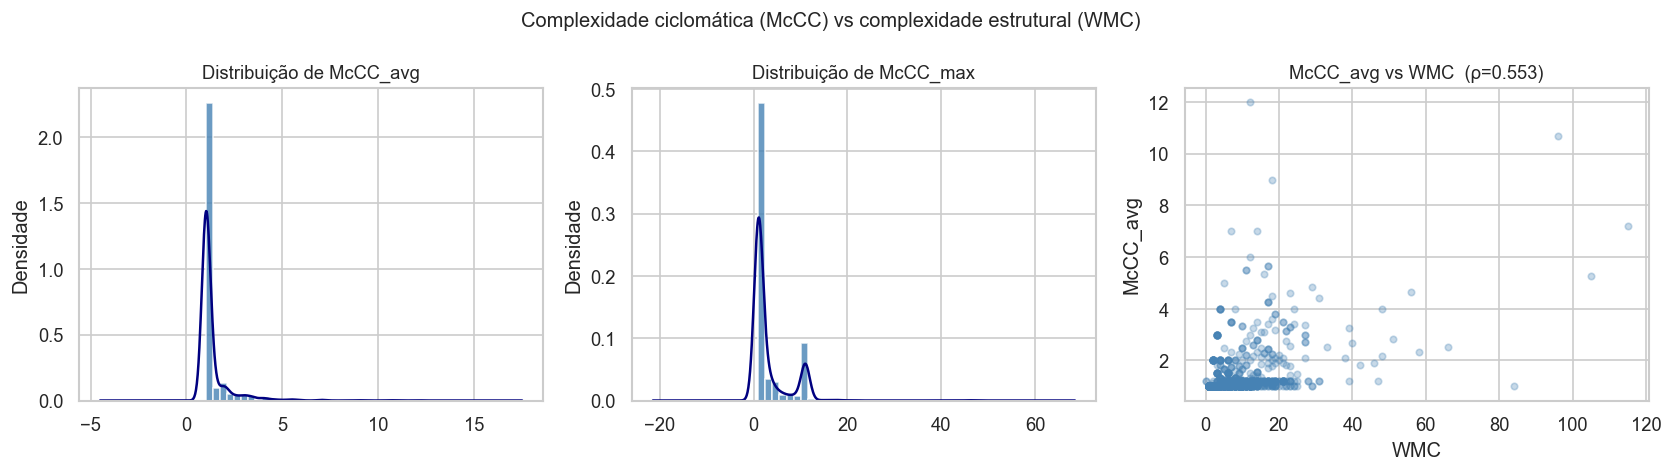

McCC por percentil:
       McCC_avg  McCC_max
count   1191.00   1191.00
mean       1.33      3.10
std        0.89      3.89
min        1.00      1.00
50%        1.00      1.00
75%        1.20      3.00
90%        2.00     11.00
95%        3.00     11.00
99%        5.26     11.00
max       12.00     46.00


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribuição McCC_avg e McCC_max
for i, col in enumerate(['McCC_avg','McCC_max']):
    axes[i].hist(df[col], bins=30, color='steelblue', alpha=0.8, edgecolor='white', density=True)
    df[col].plot.kde(ax=axes[i], color='navy', lw=1.5)
    axes[i].set_title(f'Distribuição de {col}', fontsize=11)
    axes[i].set_ylabel('Densidade')

# Dispersão McCC_avg vs WMC
axes[2].scatter(df['WMC'], df['McCC_avg'], alpha=0.3, s=15, color='steelblue')
r, p = stats.spearmanr(df['McCC_avg'], df['WMC'])
axes[2].set_xlabel('WMC'); axes[2].set_ylabel('McCC_avg')
axes[2].set_title(f'McCC_avg vs WMC  (ρ={r:.3f})', fontsize=11)

plt.suptitle('Complexidade ciclomática (McCC) vs complexidade estrutural (WMC)', fontsize=12)
plt.tight_layout()
plt.savefig('mccc.png', bbox_inches='tight')
plt.show()

print('McCC por percentil:')
print(df[['McCC_avg','McCC_max']].describe(percentiles=[.5,.75,.90,.95,.99]).round(2).to_string())

## 7. Correlação de Spearman

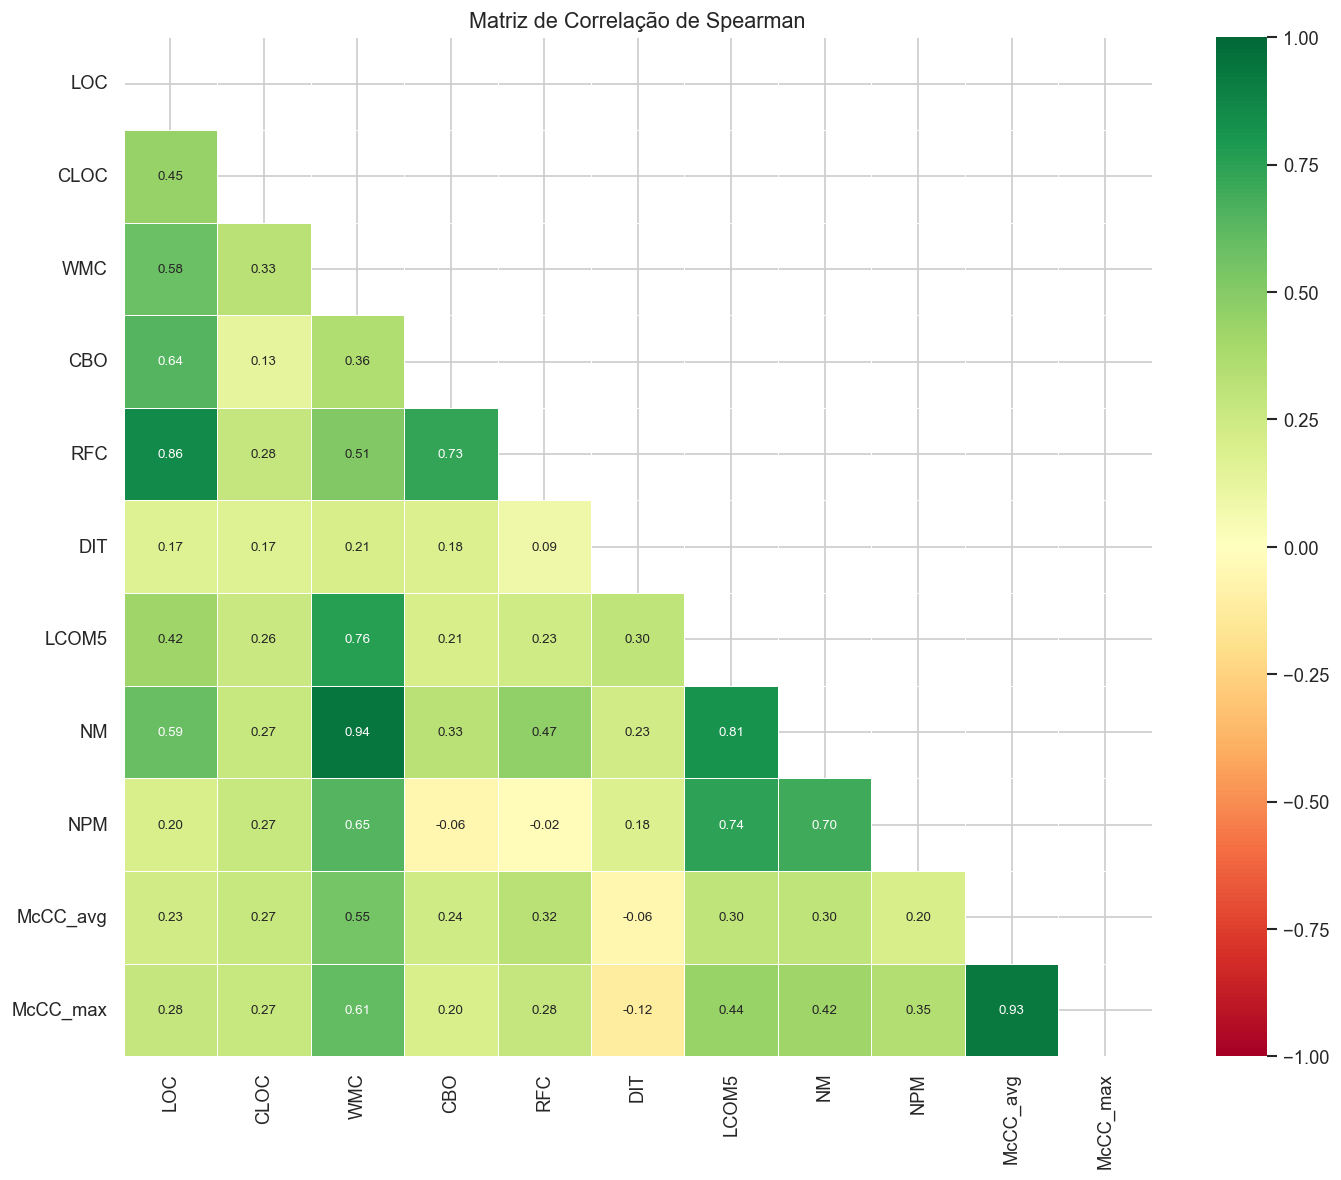

Pares com |ρ| > 0.70:
  LOC        x RFC       : ρ=+0.857
  WMC        x LCOM5     : ρ=+0.759
  WMC        x NM        : ρ=+0.939
  CBO        x RFC       : ρ=+0.732
  LCOM5      x NM        : ρ=+0.814
  LCOM5      x NPM       : ρ=+0.744
  NM         x NPM       : ρ=+0.701
  McCC_avg   x McCC_max  : ρ=+0.926


In [11]:
corr = df[METRICAS].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Matriz de Correlação de Spearman', fontsize=13)
plt.tight_layout()
plt.savefig('correlacao.png', bbox_inches='tight')
plt.show()

# Pares mais correlacionados
print('Pares com |ρ| > 0.70:')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i,j]
        if abs(v) > 0.70:
            print(f'  {corr.columns[i]:10s} x {corr.columns[j]:10s}: ρ={v:+.3f}')

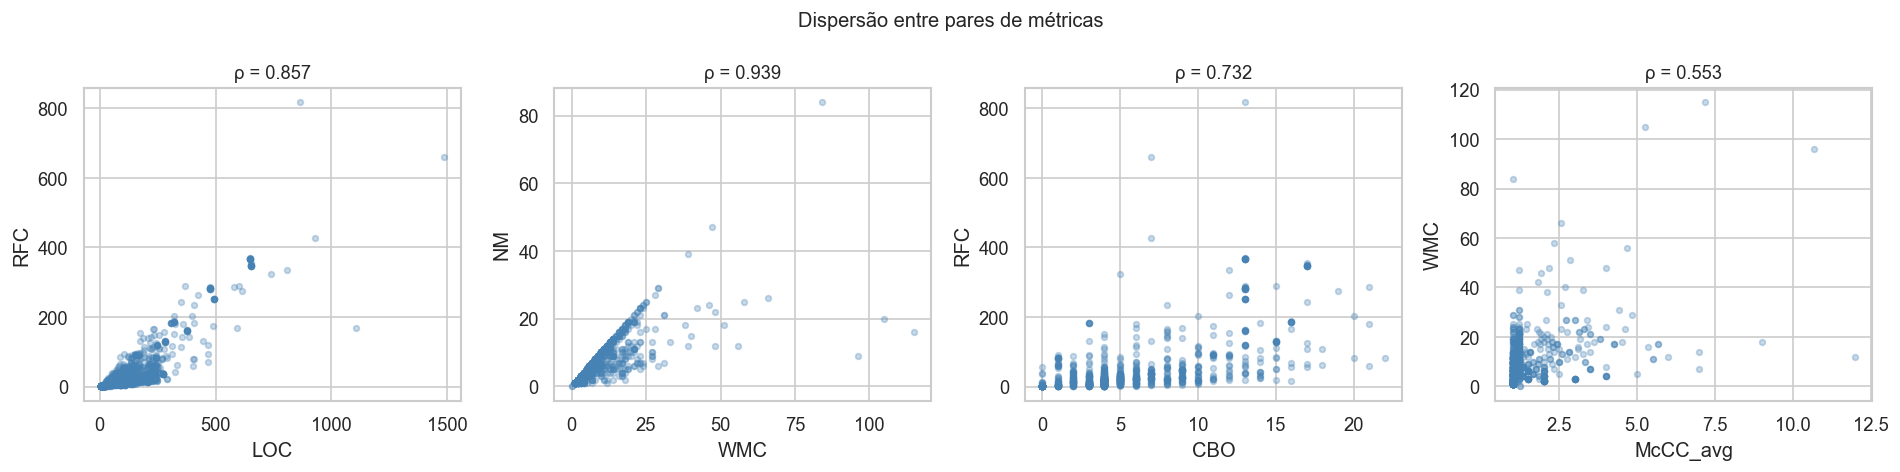

In [12]:
# Scatter: pares mais relevantes
pairs = [('LOC','RFC'), ('WMC','NM'), ('CBO','RFC'), ('McCC_avg','WMC')]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df[x], df[y], alpha=0.3, s=12, color='steelblue')
    r, _ = stats.spearmanr(df[x], df[y])
    axes[i].set_xlabel(x); axes[i].set_ylabel(y)
    axes[i].set_title(f'ρ = {r:.3f}', fontsize=11)
plt.suptitle('Dispersão entre pares de métricas', fontsize=12)
plt.tight_layout()
plt.savefig('dispersao.png', bbox_inches='tight')
plt.show()

## 8. PCA + Cluster (K-Means)

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(df[METRICAS])

pca = PCA(n_components=4)
components = pca.fit_transform(X)

print('Variância explicada por componente:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.1f}% (acumulado: {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%)')

loadings = pd.DataFrame(pca.components_.T, index=METRICAS,
                        columns=[f'PC{i+1}' for i in range(4)])
print('\nLoadings (contribuição de cada métrica):')
print(loadings.round(3).to_string())

Variância explicada por componente:
  PC1: 35.7% (acumulado: 35.7%)
  PC2: 20.3% (acumulado: 56.0%)
  PC3: 12.7% (acumulado: 68.7%)
  PC4: 10.1% (acumulado: 78.8%)

Loadings (contribuição de cada métrica):
            PC1    PC2    PC3    PC4
LOC       0.334  0.434 -0.173 -0.039
CLOC      0.221  0.094  0.219  0.346
WMC       0.452 -0.056  0.176 -0.018
CBO       0.197  0.457 -0.109  0.037
RFC       0.210  0.554 -0.146 -0.151
DIT       0.108 -0.064 -0.212  0.835
LCOM5     0.334 -0.294 -0.151  0.113
NM        0.426 -0.207 -0.249 -0.147
NPM       0.359 -0.349 -0.243 -0.150
McCC_avg  0.165  0.094  0.684  0.197
McCC_max  0.303 -0.143  0.448 -0.247


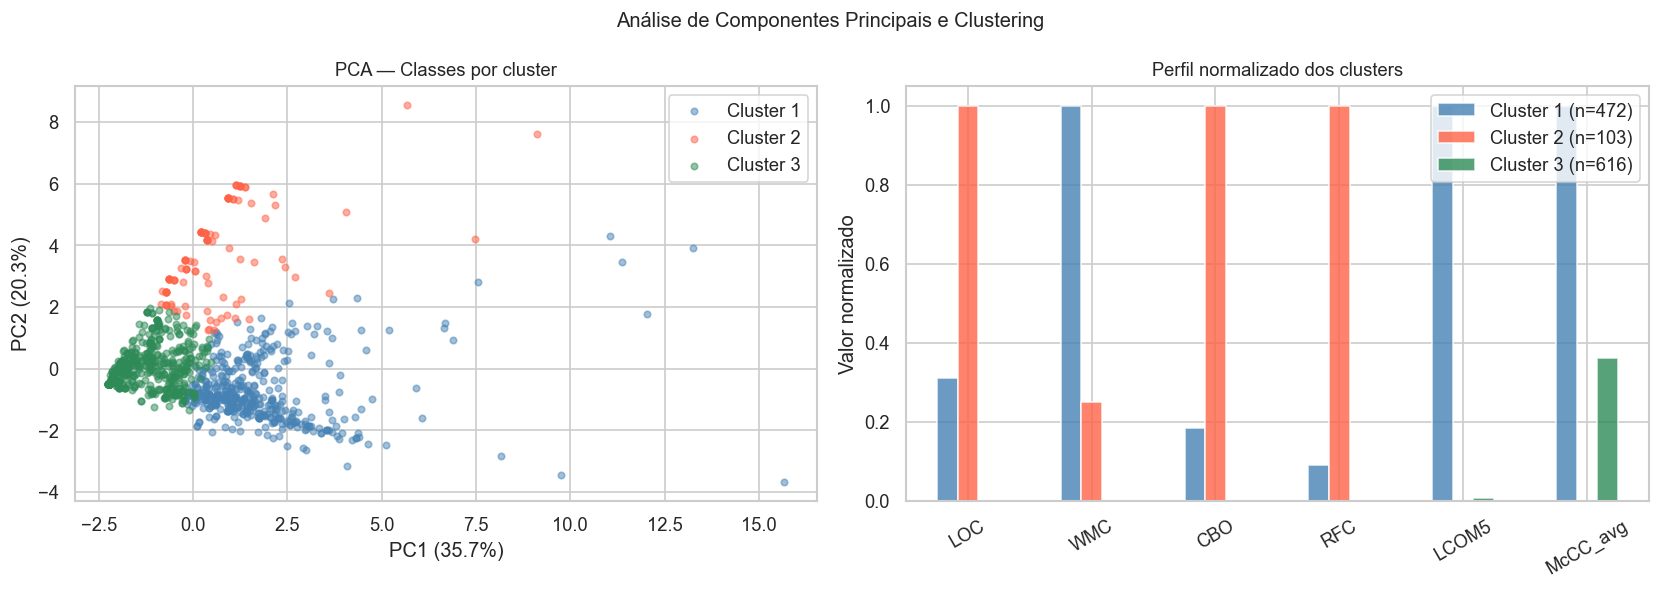


Métricas médias por cluster:
            LOC   CLOC    WMC    CBO     RFC   DIT  LCOM5     NM   NPM  McCC_avg  McCC_max
cluster                                                                                   
0        175.28  15.84  14.27   5.30   36.26  0.40   0.83  10.35  9.29      1.52      5.56
1        426.37   6.08   5.58  13.45  232.07  0.08   0.16   4.75  0.04      1.07      1.32
2         62.07   5.70   2.70   3.45   16.50  0.13   0.17   2.17  1.46      1.23      1.51

Tamanho dos clusters:
cluster
0    472
1    103
2    616


In [14]:
# K-Means com 3 clusters
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2 colorido por cluster
colors = ['steelblue','tomato','seagreen']
for k in range(3):
    mask = df['cluster'] == k
    axes[0].scatter(components[mask, 0], components[mask, 1],
                    s=15, alpha=0.5, color=colors[k], label=f'Cluster {k+1}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA — Classes por cluster', fontsize=11)
axes[0].legend()

# Perfil médio dos clusters
profile = df.groupby('cluster')[['LOC','WMC','CBO','RFC','LCOM5','McCC_avg']].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm.T.plot(kind='bar', ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title('Perfil normalizado dos clusters', fontsize=11)
axes[1].set_ylabel('Valor normalizado')
axes[1].legend([f'Cluster {i+1} (n={int((df["cluster"]==i).sum())})' for i in range(3)])
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Análise de Componentes Principais e Clustering', fontsize=12)
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight')
plt.show()

print('\nMétricas médias por cluster:')
print(df.groupby('cluster')[METRICAS].mean().round(2).to_string())
print('\nTamanho dos clusters:')
print(df['cluster'].value_counts().sort_index().to_string())

## 9. Comparação entre repositórios

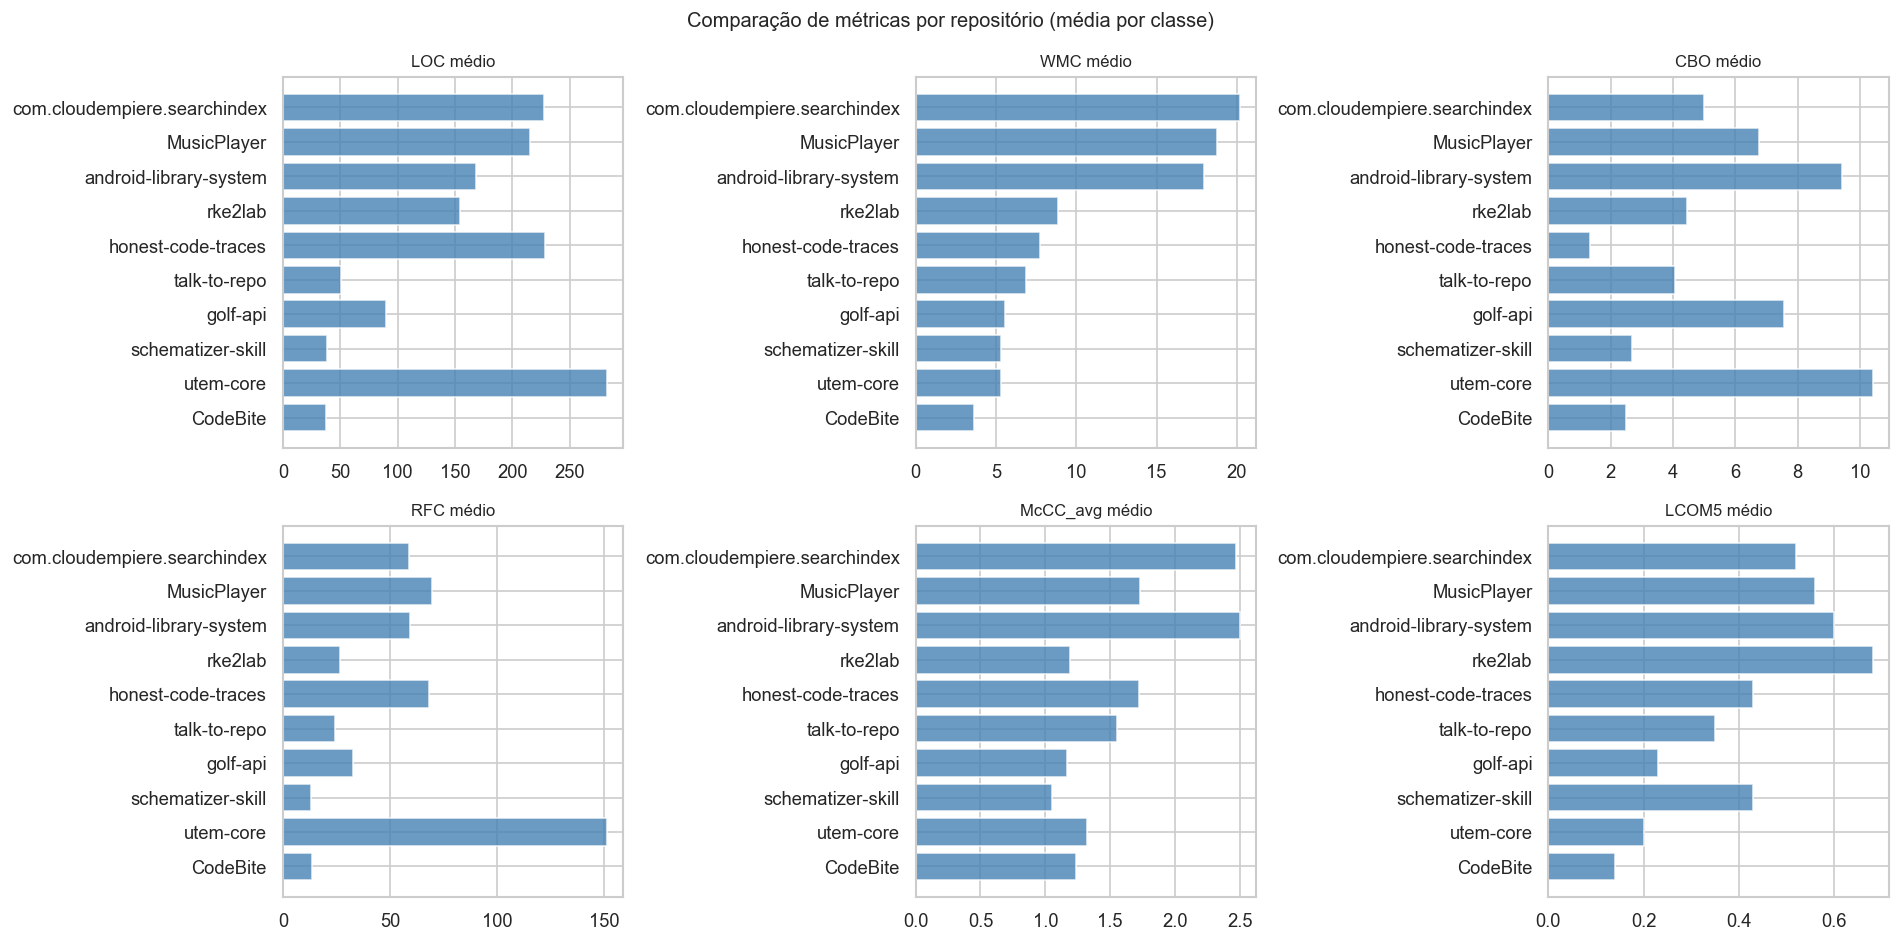

,LOC,CLOC,WMC,CBO,RFC,DIT,LCOM5,NM,NPM,McCC_avg,McCC_max,n_classes
repo,,,,,,,,,,,,
cloudempiere/com.cloudempiere.searchindex,228.03,69.91,20.18,5.00,58.65,0.53,0.52,8.85,7.74,2.47,5.88,34
JackZho/MusicPlayer,215.50,3.50,18.75,6.75,69.75,0.75,0.56,8.75,5.75,1.73,4.50,4
JackZho/android-library-system,168.59,12.15,17.93,9.44,59.31,0.69,0.60,8.28,5.98,2.50,4.78,54
nxmatic/rke2lab,154.23,11.20,8.89,4.45,26.49,0.38,0.68,7.66,7.09,1.19,4.43,506
adamzwasserman/honest-code-traces,228.35,32.46,7.77,1.35,68.12,0.12,0.43,3.92,0.54,1.72,4.04,26
sivaprasadreddy/talk-to-repo,50.73,1.00,6.87,4.07,24.27,0.00,0.35,3.67,2.93,1.55,2.33,15
tim-mila/golf-api,90.03,3.09,5.57,7.57,32.87,0.13,0.23,4.99,1.27,1.17,1.46,70
akrishnanDG/schematizer-skill,38.78,0.72,5.33,2.67,13.00,0.00,0.43,5.22,5.22,1.05,1.11,18
shossain786/utem-core,282.61,6.68,5.32,10.41,151.17,0.02,0.20,3.77,1.49,1.32,1.76,155


In [15]:
repo_stats = df.groupby('repo')[METRICAS].mean().round(2)
repo_stats['n_classes'] = df.groupby('repo').size()
repo_stats = repo_stats.sort_values('WMC', ascending=False)
repo_labels = [r.split('/')[-1] for r in repo_stats.index]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
cols_repo = ['LOC','WMC','CBO','RFC','McCC_avg','LCOM5']
for i, col in enumerate(cols_repo):
    axes[i].barh(repo_labels, repo_stats[col], color='steelblue', alpha=0.8)
    axes[i].set_title(f'{col} médio', fontsize=10)
    axes[i].invert_yaxis()
plt.suptitle('Comparação de métricas por repositório (média por classe)', fontsize=12)
plt.tight_layout()
plt.savefig('repos_comparacao.png', bbox_inches='tight')
plt.show()

repo_stats

## 10. Síntese automática

In [16]:
print('=== SÍNTESE PARA O ARTIGO ===')
print(f'Classes analisadas : {len(df)}')
print(f'Repositórios       : {df["repo"].nunique()}')
print()
for col in ['LOC','WMC','CBO','RFC','DIT','LCOM5','McCC_avg','McCC_max']:
    s = df[col]
    print(f'{col:10s}: média={s.mean():.2f}, mediana={s.median():.0f}, DP={s.std():.2f}, max={s.max():.0f}')
print()
print('Code smells:')
for k,v in smells.items():
    print(f"  {k.replace(chr(10),' '):40s}: {v} ({v/len(df)*100:.1f}%)")
print()
print('Pares altamente correlacionados (ρ>0.70):')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i,j]
        if abs(v) > 0.70:
            print(f'  {corr.columns[i]} x {corr.columns[j]}: ρ={v:+.3f}')

=== SÍNTESE PARA O ARTIGO ===
Classes analisadas : 1191
Repositórios       : 10

LOC       : média=138.44, mediana=110, DP=142.52, max=1485
WMC       : média=7.53, mediana=5, DP=9.43, max=115
CBO       : média=5.05, mediana=4, DP=4.36, max=22
RFC       : média=42.97, mediana=18, DP=75.15, max=818
DIT       : média=0.23, mediana=0, DP=0.42, max=1
LCOM5     : média=0.43, mediana=0, DP=0.41, max=1
McCC_avg  : média=1.33, mediana=1, DP=0.89, max=12
McCC_max  : média=3.10, mediana=1, DP=3.89, max=46

Code smells:
  God Class (WMC>20 & LCOM5>0.7)          : 53 (4.5%)
  Alta Complexidade (McCC_max>10)         : 172 (14.4%)
  Acoplamento Excessivo (CBO>14)          : 52 (4.4%)
  Classe Grande (LOC>500)                 : 32 (2.7%)
  Interface Inchada (NPM>20)              : 21 (1.8%)

Pares altamente correlacionados (ρ>0.70):
  LOC x RFC: ρ=+0.857
  WMC x LCOM5: ρ=+0.759
  WMC x NM: ρ=+0.939
  CBO x RFC: ρ=+0.732
  LCOM5 x NM: ρ=+0.814
  LCOM5 x NPM: ρ=+0.744
  NM x NPM: ρ=+0.701
  McCC_avg x M